# Financial Text Exploration

**Project:** Financial Planning & Analysis Intelligence Platform

**Notebook:** `03-financial-text-exploration.ipynb`

In [4]:
# !pip install WordCloud

In [5]:
# ==========================================
# Notebook 03
# Financial Text Exploration
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from collections import Counter

import nltk

from nltk.corpus import stopwords

from wordcloud import WordCloud

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vinna\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [6]:
financial_df = pd.read_csv("../data/financial_documents_cleaned.csv")

financial_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,combined_text,clean_text,character_count,sentences,chunks
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,\n Demand remained strong across enterp...,Demand remained strong across enterprise custo...,299,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,\n Enterprise adoption accelerated.\n ...,Enterprise adoption accelerated. Pricing press...,239,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,\n Customer demand exceeded expectation...,Customer demand exceeded expectations. Supply ...,269,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,\n Record quarter performance.\n ...,Record quarter performance. Management expects...,260,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,\n Strong start to the fiscal year driv...,Strong start to the fiscal year driven by ente...,460,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...


In [7]:
print("Rows:", len(financial_df))

print("Columns:", len(financial_df.columns))

financial_df.columns

Rows: 12
Columns: 15


Index(['ticker', 'quarter', 'revenue_million', 'gross_margin_pct',
       'operating_income_million', 'net_income_million', 'eps',
       'earnings_call', 'risk_factors', 'mda_section', 'combined_text',
       'clean_text', 'character_count', 'sentences', 'chunks'],
      dtype='object')

In [8]:
financial_df[["quarter", "revenue_million", "gross_margin_pct", "eps"]]

,quarter,revenue_million,gross_margin_pct,eps
0,2023-Q1,120,58,1.20
1,2023-Q2,128,60,1.35
2,2023-Q3,138,61,1.52
3,2023-Q4,150,63,1.72
4,2024-Q1,158,62,1.85
5,2024-Q2,167,64,2.05
6,2024-Q3,174,64,2.18
7,2024-Q4,190,65,2.45
8,2025-Q1,198,64,2.52
9,2025-Q2,210,66,2.80


In [9]:
all_text = " ".join(financial_df["clean_text"].astype(str))

In [10]:
financial_df[["quarter", "character_count"]]

,quarter,character_count
0,2023-Q1,299
1,2023-Q2,239
2,2023-Q3,269
3,2023-Q4,260
4,2024-Q1,460
5,2024-Q2,436
6,2024-Q3,482
7,2024-Q4,540
8,2025-Q1,463
9,2025-Q2,464


In [11]:
def tokenize_text(text):

    text = text.lower()

    tokens = text.split()

    tokens = [token for token in tokens if token.isalpha()]

    return tokens

In [12]:
tokens = tokenize_text(all_text)

len(tokens)

543

In [13]:
tokens

['demand',
 'remained',
 'strong',
 'across',
 'enterprise',
 'we',
 'expect',
 'continued',
 'growth',
 'next',
 'supply',
 'chain',
 'constraints',
 'are',
 'gradually',
 'inflation',
 'remains',
 'a',
 'global',
 'logistics',
 'costs',
 'remain',
 'management',
 'believes',
 'demand',
 'trends',
 'remain',
 'customer',
 'retention',
 'continues',
 'to',
 'enterprise',
 'adoption',
 'pricing',
 'pressure',
 'has',
 'we',
 'expect',
 'strong',
 'momentum',
 'in',
 'competitive',
 'pressure',
 'currency',
 'fluctuations',
 'may',
 'impact',
 'new',
 'product',
 'launches',
 'contributed',
 'pipeline',
 'remains',
 'customer',
 'demand',
 'exceeded',
 'supply',
 'chain',
 'bottlenecks',
 'largely',
 'international',
 'expansion',
 'geopolitical',
 'uncertainty',
 'regulatory',
 'changes',
 'may',
 'affect',
 'strong',
 'customer',
 'growth',
 'across',
 'profitability',
 'improved',
 'record',
 'quarter',
 'management',
 'expects',
 'continued',
 'demand',
 'remains',
 'exceptionally',


In [14]:
stop_words = set(stopwords.words("english"))

filtered_tokens = [token for token in tokens if token not in stop_words]

In [15]:
len(filtered_tokens)

437

In [16]:
word_counts = Counter(filtered_tokens)

top_words = word_counts.most_common(20)

top_words

[('strong', 9),
 ('remains', 8),
 ('could', 7),
 ('growth', 6),
 ('expansion', 6),
 ('revenue', 6),
 ('operating', 6),
 ('enterprise', 5),
 ('customer', 5),
 ('demand', 4),
 ('across', 4),
 ('costs', 4),
 ('remain', 4),
 ('may', 4),
 ('record', 4),
 ('year', 4),
 ('higher', 4),
 ('market', 4),
 ('global', 3),
 ('pressure', 3)]

In [17]:
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

In [18]:
top_words_df

,word,count
0,strong,9
1,remains,8
2,could,7
3,growth,6
4,expansion,6
5,revenue,6
6,operating,6
7,enterprise,5
8,customer,5
9,demand,4


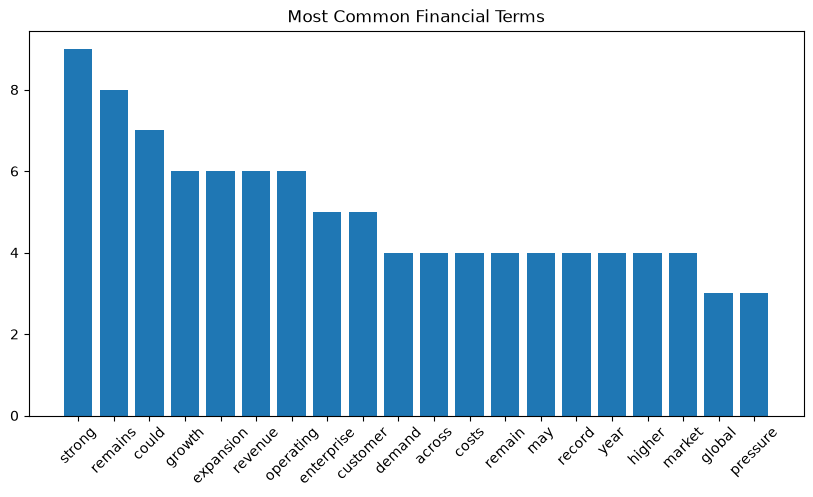

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(top_words_df["word"], top_words_df["count"])

plt.xticks(rotation=45)

plt.title("Most Common Financial Terms")

plt.show()

In [20]:
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(
    " ".join(filtered_tokens)
)

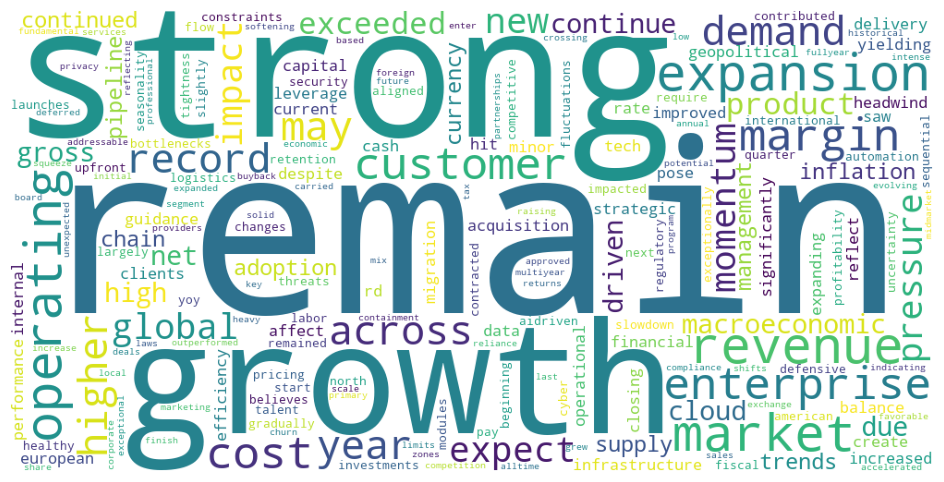

In [21]:
plt.figure(figsize=(12, 6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [22]:
risk_keywords = [
    "risk",
    "inflation",
    "competition",
    "uncertainty",
    "regulatory",
    "costs",
]

In [23]:
risk_counts = {}

for keyword in risk_keywords:

    risk_counts[keyword] = filtered_tokens.count(keyword)

In [24]:
risk_df = pd.DataFrame(risk_counts.items(), columns=["keyword", "count"])

risk_df

,keyword,count
0,risk,0
1,inflation,2
2,competition,1
3,uncertainty,1
4,regulatory,1
5,costs,4


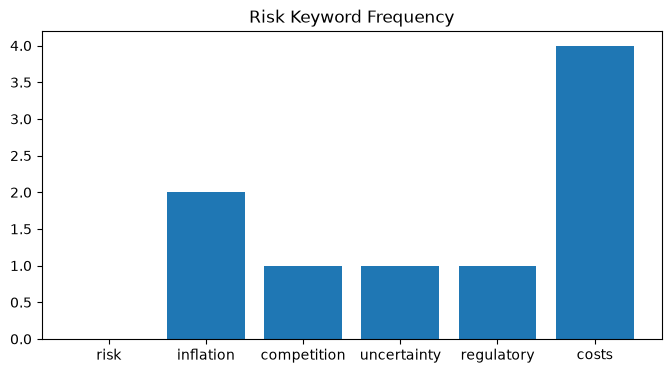

In [25]:
plt.figure(figsize=(8, 4))

plt.bar(risk_df["keyword"], risk_df["count"])

plt.title("Risk Keyword Frequency")

plt.show()

In [26]:
growth_keywords = ["growth", "demand", "expansion", "pipeline", "customers", "momentum"]

In [27]:
growth_counts = {}

for keyword in growth_keywords:

    growth_counts[keyword] = filtered_tokens.count(keyword)

In [28]:
growth_df = pd.DataFrame(growth_counts.items(), columns=["keyword", "count"])

growth_df

,keyword,count
0,growth,6
1,demand,4
2,expansion,6
3,pipeline,2
4,customers,0
5,momentum,3


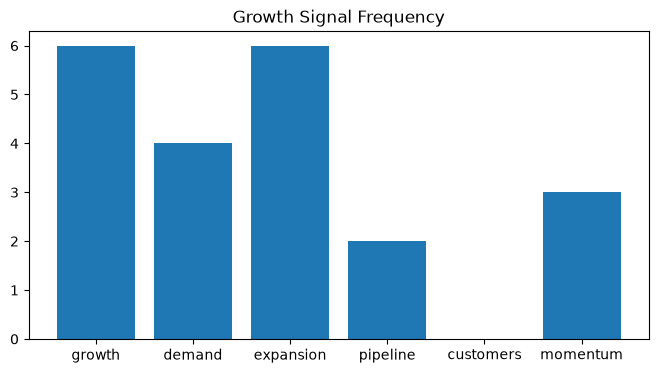

In [29]:
plt.figure(figsize=(8, 4))

plt.bar(growth_df["keyword"], growth_df["count"])

plt.title("Growth Signal Frequency")

plt.show()

In [30]:
quarter_text_analysis = []

In [31]:
for _, row in financial_df.iterrows():

    text = row["clean_text"].lower()

    growth_score = sum(text.count(keyword) for keyword in growth_keywords)

    risk_score = sum(text.count(keyword) for keyword in risk_keywords)

    quarter_text_analysis.append(
        {
            "quarter": row["quarter"],
            "growth_score": growth_score,
            "risk_score": risk_score,
            "revenue": row["revenue_million"],
        }
    )

In [32]:
quarter_analysis_df = pd.DataFrame(quarter_text_analysis)

quarter_analysis_df

,quarter,growth_score,risk_score,revenue
0,2023-Q1,4,2,120
1,2023-Q2,2,0,128
2,2023-Q3,3,2,138
3,2023-Q4,3,1,150
4,2024-Q1,1,0,158
5,2024-Q2,2,1,167
6,2024-Q3,2,2,174
7,2024-Q4,3,0,190
8,2025-Q1,2,1,198
9,2025-Q2,2,1,210


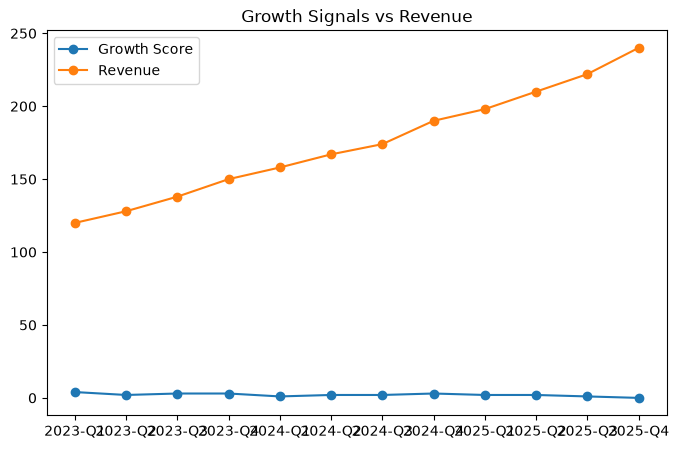

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    quarter_analysis_df["quarter"],
    quarter_analysis_df["growth_score"],
    marker="o",
    label="Growth Score",
)

plt.plot(
    quarter_analysis_df["quarter"],
    quarter_analysis_df["revenue"],
    marker="o",
    label="Revenue",
)

plt.legend()

plt.title("Growth Signals vs Revenue")

plt.show()

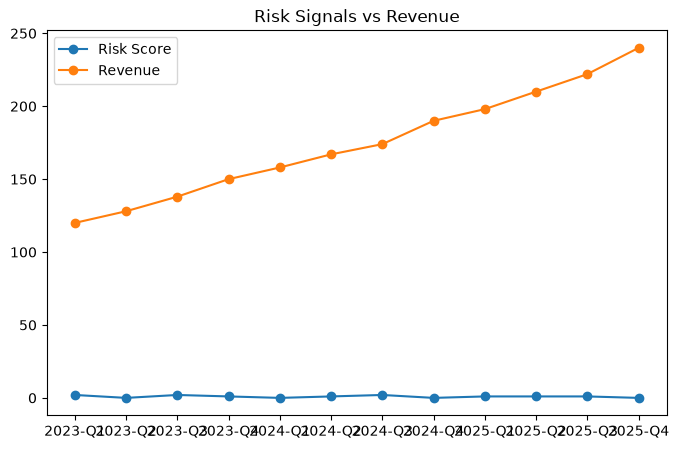

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    quarter_analysis_df["quarter"],
    quarter_analysis_df["risk_score"],
    marker="o",
    label="Risk Score",
)

plt.plot(
    quarter_analysis_df["quarter"],
    quarter_analysis_df["revenue"],
    marker="o",
    label="Revenue",
)

plt.legend()

plt.title("Risk Signals vs Revenue")

plt.show()

In [35]:
quarter_analysis_df.to_csv("../data/financial_text_analysis.csv", index=False)

In [36]:
top_words_df.to_csv("../data/financial_top_words.csv", index=False)

In [37]:
saved_df = pd.read_csv("../data/financial_text_analysis.csv")

saved_df.head()

,quarter,growth_score,risk_score,revenue
0,2023-Q1,4,2,120
1,2023-Q2,2,0,128
2,2023-Q3,3,2,138
3,2023-Q4,3,1,150
4,2024-Q1,1,0,158
